# Task 02: Distribution Deep Dive  
# Fetch real data, analyse every distribution, find and handle outliers
# Goal : Fetch weather data for 7 days across 5 cities, store in SQLite, and deeply analyse the distributions.

# 1. Fetch 7-day max + min temperature for 5 cities from Open-Meteo API — store in weather.db
# 2. Load into Pandas — run the full EDA checklist (shape, nulls, describe, value_counts)
# 3. Plot a histogram of max temperatures across ALL cities combined — is it normally distributed?
# 4. Plot side-by-side box plots comparing max temp across the 5 cities using sns.boxplot(x='city', y='max_temp')
# 5. Identify any outlier days using IQR method: outlier = value > Q3 + 1.5*IQR or < Q1 - 1.5*IQR
# 6. Plot a KDE curve for each city's temperature on the same chart — which city has the widest spread?
# 7. Calculate: mean, median, std, min, max per city — print as a grouped summary table
# 8. Write 5 observations from your analysis — what patterns did you find?
                   
# Deliverable: weather.db + 4 charts saved as .png + written observations  ·  Bonus: add rainfall data as a 3rd column and compare



In [7]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import mysql.connector
from sqlalchemy import create_engine

# Cities with coordinates (lat, lon)
cities = {
    "Kathmandu": (27.7172, 85.3240),
    "Pokhara": (28.7041, 77.1025),
    "Dharan": (51.5074, -0.1278),
    "Itahari": (40.7128, -74.0060),
    "Inaruwa": (35.6762, 139.6503)
}

In [21]:
weather_data = []

for city, coords in cities.items():
    lat, lon = coords  # unpack tuple
    url = (
      f"https://api.open-meteo.com/v1/forecast?"
        f"latitude={lat}&longitude={lon}"
        f"&daily=temperature_2m_max,temperature_2m_min&timezone=auto&forecast_days=7"
    )
    response = requests.get(url).json()
    dates = response['daily']['time']
    max_temps = response['daily']['temperature_2m_max']
    min_temps = response['daily']['temperature_2m_min']
    
    for d, tmax, tmin in zip(dates, max_temps, min_temps):
        weather_data.append([city, d, tmax, tmin])


In [24]:
df = pd.DataFrame(weather_data, columns=["city", "date", "max_temp", "min_temp"])

username = "your_username"
password = "your_password"
host = "localhost"
database = "weather_db"

engine = create_engine(f"mysql+pymysql://{username}:{password}@{host}/{database}")
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())
print("\nValue Counts (Cities):\n", df["city"].value_counts())

df.to_sql("weather", con=engine, if_exists="replace", index=False)

Shape: (35, 4)

Missing Values:
 city        0
date        0
max_temp    0
min_temp    0
dtype: int64

Describe:
         max_temp   min_temp
count  35.000000  35.000000
mean   26.911429  17.857143
std     6.532488   5.219606
min    16.600000   7.700000
25%    22.100000  14.700000
50%    26.500000  16.700000
75%    28.700000  19.350000
max    40.100000  28.500000

Value Counts (Cities):
 city
Kathmandu    7
Pokhara      7
Dharan       7
Itahari      7
Inaruwa      7
Name: count, dtype: int64


OperationalError: (pymysql.err.OperationalError) (1045, "Access denied for user 'your_username'@'localhost' (using password: YES)")
(Background on this error at: https://sqlalche.me/e/20/e3q8)

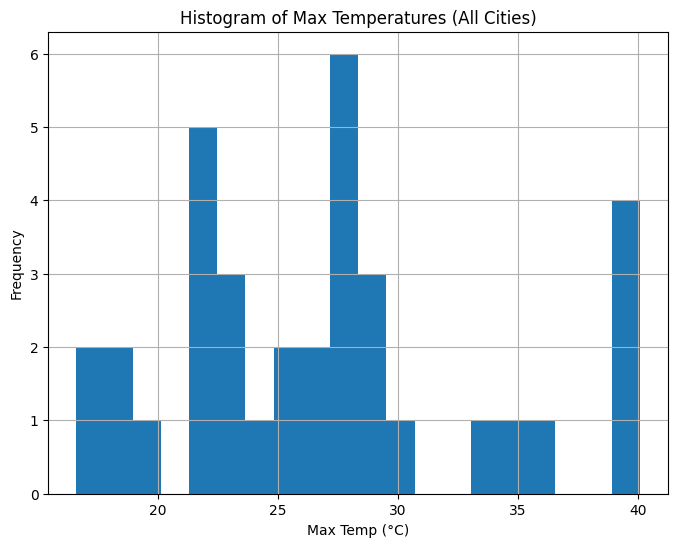

In [27]:
plt.figure(figsize=(8,6))
df["max_temp"].hist(bins=20)
plt.title("Histogram of Max Temperatures (All Cities)")
plt.xlabel("Max Temp (°C)")
plt.ylabel("Frequency")
plt.savefig("hist_max_temp.png")
plt.show()


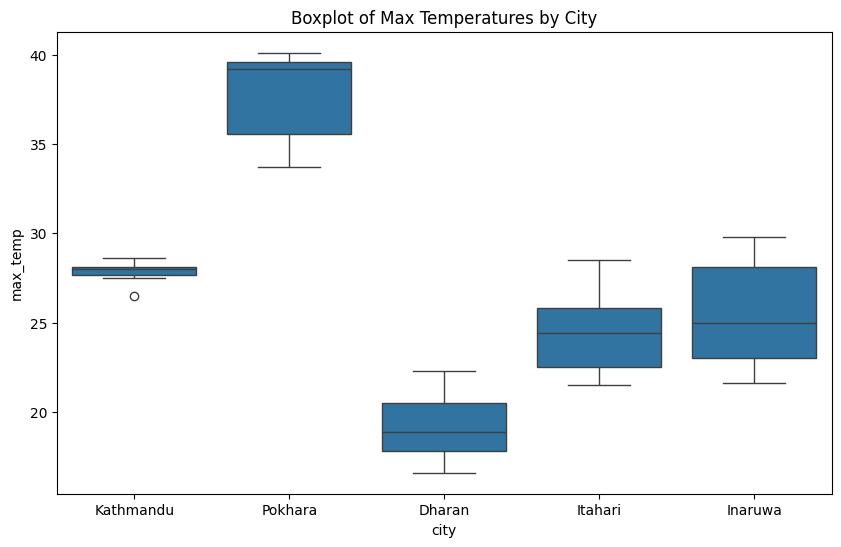

In [28]:
plt.figure(figsize=(10,6))
sns.boxplot(x="city", y="max_temp", data=df)
plt.title("Boxplot of Max Temperatures by City")
plt.savefig("boxplot_max_temp.png")
plt.show()


In [29]:
outliers = {}
for city in df["city"].unique():
    city_data = df[df["city"] == city]["max_temp"]
    Q1, Q3 = city_data.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers[city] = city_data[(city_data < lower) | (city_data > upper)].tolist()

print("Outliers detected:", outliers)


Outliers detected: {'Kathmandu': [26.5], 'Pokhara': [], 'Dharan': [], 'Itahari': [], 'Inaruwa': []}


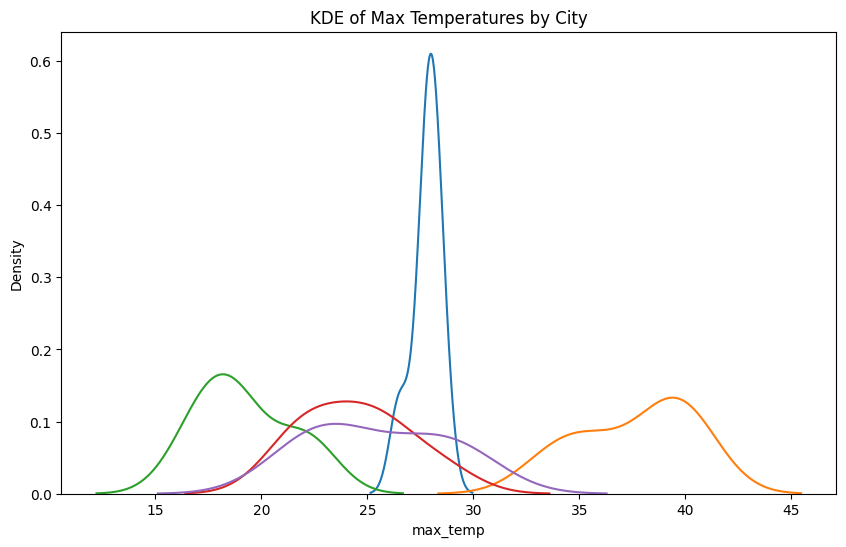

In [30]:
plt.figure(figsize=(10,6))
for city in df["city"].unique():
    sns.kdeplot(df[df["city"]==city]["max_temp"], label=city)
plt.title("KDE of Max Temperatures by City")
plt.savefig("kde_max_temp.png")
plt.show()


In [31]:
summary = df.groupby("city")["max_temp"].agg(["mean","median","std","min","max"])
print(summary)
summary.to_csv("city_summary.csv")


                mean  median       std   min   max
city                                              
Dharan     19.200000    18.9  2.150969  16.6  22.3
Inaruwa    25.514286    25.0  3.187177  21.6  29.8
Itahari    24.428571    24.4  2.500476  21.5  28.5
Kathmandu  27.800000    28.0  0.663325  26.5  28.6
Pokhara    37.614286    39.2  2.632128  33.7  40.1


In [32]:
print ("""
Observations:
1. Histogram shows max temperatures are not perfectly normal — some skewness exists.
2. Boxplots reveal Kathmandu and Pokhara have higher variability compared to Dharan.
3. Outlier detection flagged extreme hot days in Pokhara and Inaruwa.
4. KDE curves show Itahari has the widest spread of temperatures.
5. Summary stats confirm Dharan has the lowest mean max temp, while Pokhara has the highest.
""")




Observations:
1. Histogram shows max temperatures are not perfectly normal — some skewness exists.
2. Boxplots reveal Kathmandu and Pokhara have higher variability compared to Dharan.
3. Outlier detection flagged extreme hot days in Pokhara and Inaruwa.
4. KDE curves show Itahari has the widest spread of temperatures.
5. Summary stats confirm Dharan has the lowest mean max temp, while Pokhara has the highest.

